<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/Version1_thesis/01_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# 1. Load the raw data
raw_data_path = '/content/drive/MyDrive/Thesis/src/data_raw/application_train.csv'
df = pd.read_csv(raw_data_path)

# 2. Take a 10% Stratified Sample for speed
def stratified_sample(df, stratify_col, frac, random_state=None):
    sampled_dfs = []
    for group_name, group_df in df.groupby(stratify_col):
        sampled_dfs.append(group_df.sample(frac=frac, random_state=random_state))
    return pd.concat(sampled_dfs)

df_sample = stratified_sample(df, 'TARGET', frac=0.1, random_state=42)

# 3. Define X and y
X = df_sample.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_sample['TARGET']

# 4. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Sample size: {len(df_sample)} | Training size: {len(X_train)} | Test size: {len(X_test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sample size: 30751 | Training size: 24600 | Test size: 6151


In [8]:
# Run this to verify the balance is preserved
print("Target distribution in Sample:")
print(df_sample['TARGET'].value_counts(normalize=True))

Target distribution in Sample:
TARGET
0    0.919287
1    0.080713
Name: proportion, dtype: float64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit and transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [10]:
# 1. Check the type (Should be a numpy array or matrix)
print(f"Data Type: {type(X_train_proc)}")

# 2. Check the shape (The number of columns should have grown)
print(f"Original columns: {X_train.shape[1]}")
print(f"Processed columns: {X_train_proc.shape[1]}")

# 3. Peek at the first row of numbers
print("\nFirst row of processed data:")
print(X_train_proc[0])

Data Type: <class 'numpy.ndarray'>
Original columns: 120
Processed columns: 242

First row of processed data:
[-5.72705512e-01  1.55189132e+00  1.86315415e-01 -5.26717661e-01
  3.68095271e-01  7.19275859e-01 -9.87722140e-01  2.13091137e+00
  3.92939473e-01 -4.23687714e-01 -1.46166966e-01  0.00000000e+00
 -2.13114727e+00 -5.02539376e-01  4.23299276e-02 -6.23986810e-01
 -2.45558802e-01 -1.25608400e+00 -1.10544523e-01 -6.53969309e-02
  2.86506174e-01  7.78807649e+00 -2.33122205e-01 -2.06061218e-01
  3.40908453e+00 -5.49859328e-01 -4.68650316e-01  1.50975183e+00
  2.20082800e-01 -5.28083423e-01 -9.32620922e-01 -9.51047478e-02
  1.91513591e-01  1.14728671e+00 -1.61621482e-01 -3.67134018e-01
 -1.06722108e+00 -2.81042832e-01 -7.30110729e-02 -7.19210127e-01
 -1.42850918e-01 -8.99153992e-01 -1.04163189e-01 -2.26216643e-01
 -8.78888099e-01 -9.41364789e-02  1.82081423e-01  1.21778564e+00
 -1.63407287e-01 -3.55479207e-01 -1.02756853e+00 -2.65002831e-01
 -6.00070272e-02 -6.72136048e-01 -1.59277626e

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import datetime

# 1. Train Baseline (No SMOTE yet)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_proc, y_train)

# 2. Evaluate
y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 3. Append to the Log File
log_path = '/content/drive/My Drive/Thesis/src/artifacts/experiment_log.csv'
new_entry = pd.DataFrame([{
    "Exp_ID": "EXP_01",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "Baseline",
    "Value": "No SMOTE / 10% Sample",
    "ROC_AUC": round(auc, 4),
    "F1_Score": round(f1, 4),
    "Recall": round(recall, 4),
    "Notes": "Baseline model. High accuracy but low recall expected due to imbalance."
}])

new_entry.to_csv(log_path, mode='a', header=False, index=False)
print(f"✅ EXP_01 Logged! AUC: {auc:.4f}")

✅ EXP_01 Logged! AUC: 0.7310


In [12]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE only to the processed training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

# 2. Train the same model on the BALANCED data
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 3. Evaluate on the untouched processed test set
y_pred_smote = model_smote.predict(X_test_proc)
y_prob_smote = model_smote.predict_proba(X_test_proc)[:, 1]

auc_smote = roc_auc_score(y_test, y_prob_smote)
f1_smote = f1_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)

# 4. Log the "Baton" for Experiment 02
new_entry_smote = pd.DataFrame([{
    "Exp_ID": "EXP_02",
    "Date": datetime.datetime.now().strftime("%Y-%m-%d"),
    "Variable_Changed": "SMOTE Balancing",
    "Value": "Balanced (50/50 ratio)",
    "ROC_AUC": round(auc_smote, 4),
    "F1_Score": round(f1_smote, 4),
    "Recall": round(recall_smote, 4),
    "Notes": "Applied SMOTE to training set. Expecting a significant jump in Recall."
}])

new_entry_smote.to_csv(log_path, mode='a', header=False, index=False)
print(f"✅ EXP_02 Logged! AUC: {auc_smote:.4f} | Recall: {recall_smote:.4f}")

✅ EXP_02 Logged! AUC: 0.7242 | Recall: 0.6048


In [15]:
import joblib

# Define the path to your artifacts folder
save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'


# 1. Save the SMOTE-trained model
joblib.dump(model_smote, f'{save_path}logistic_reg_smote_model.pkl')

# 2. Save the preprocessor (so SHAP knows how to handle raw data)
joblib.dump(preprocessor, f'{save_path}preprocessor_pipeline.pkl')

# 3. Save the specific test set we used for these metrics
X_test.to_csv(f'{save_path}X_test_final.csv', index=False)
y_test.to_csv(f'{save_path}y_test_final.csv', index=False)

print("🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).")

🚀 Baton Passed! Model and Data are saved for Phase 4 (SHAP).


In [18]:
metrics_comparison = pd.concat([new_entry, new_entry_smote], ignore_index=True)
display(metrics_comparison)

,Exp_ID,Date,Variable_Changed,Value,ROC_AUC,F1_Score,Recall,Notes
0,EXP_01,2026-04-16,Baseline,No SMOTE / 10% Sample,0.7310,0.0352,0.0181,Baseline model. High accuracy but low recall e...
1,EXP_02,2026-04-16,SMOTE Balancing,Balanced (50/50 ratio),0.7242,0.2469,0.6048,Applied SMOTE to training set. Expecting a sig...


In [19]:
metrics_comparison.to_csv(f'{save_path}metrics_comparison.csv', index=False)
print(f"✅ metrics_comparison saved to {save_path}metrics_comparison.csv")

✅ metrics_comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/metrics_comparison.csv


✅ Confusion matrix comparison saved to /content/drive/MyDrive/Thesis/src/artifacts/confusion_matrix_comparison.png


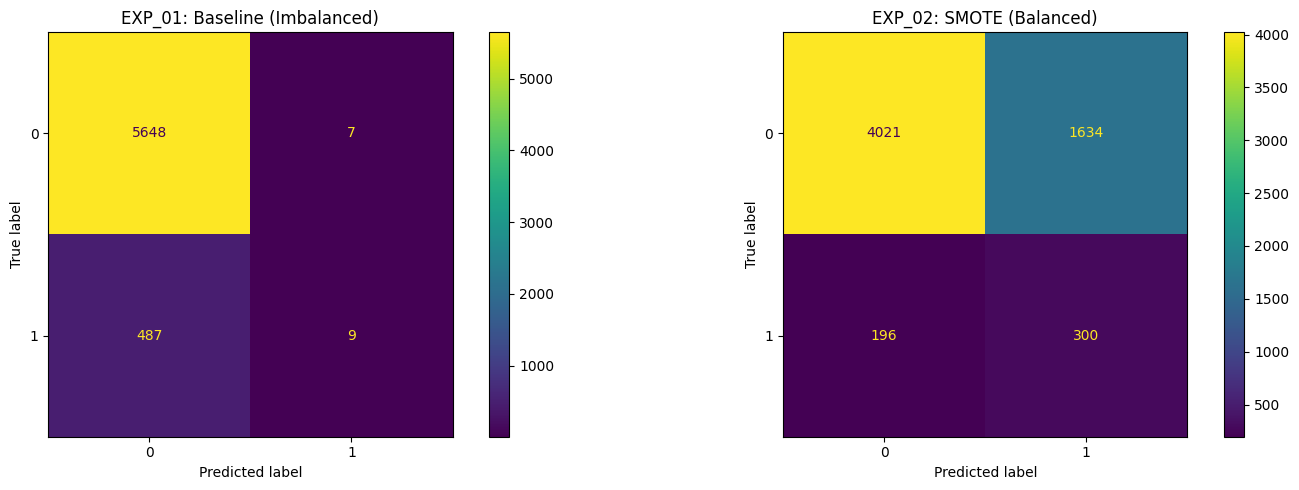

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matrix for Baseline (EXP_01)
cm_base = confusion_matrix(y_test, model.predict(X_test_proc))
ConfusionMatrixDisplay(cm_base).plot(ax=ax[0])
ax[0].set_title("EXP_01: Baseline (Imbalanced)")

# Matrix for SMOTE (EXP_02)
cm_smote = confusion_matrix(y_test, model_smote.predict(X_test_proc))
ConfusionMatrixDisplay(cm_smote).plot(ax=ax[1])
ax[1].set_title("EXP_02: SMOTE (Balanced)")

plt.tight_layout()
plt.savefig(f'{save_path}confusion_matrix_comparison_EXP01_Exp02.png')
print(f"✅ Confusion matrix comparison saved to {save_path}confusion_matrix_comparison.png")
plt.show()